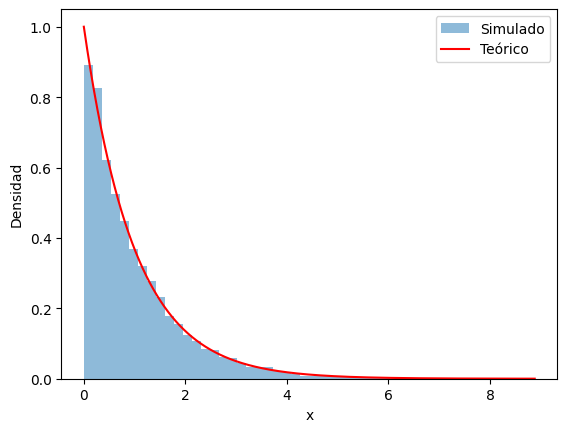

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

N = 10**4
x0 = 1

w = np.random.uniform(0, 1, N)

x = -x0 * np.log(1 - w)

t = np.linspace(0, np.max(x), N)
teorico = 1/x0 * np.exp(-(t/x0))

plt.hist(x=x, bins=50, density=True, alpha=0.5, label='Simulado')
plt.plot(t, teorico, 'r-', label='Teórico')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.show()

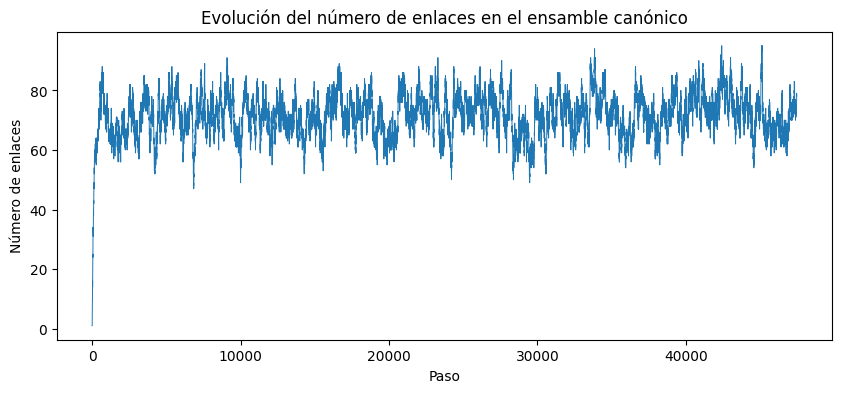

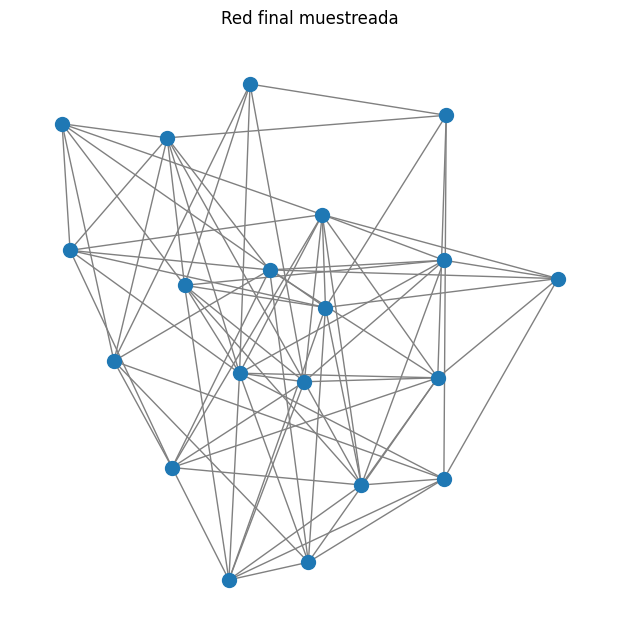

In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def metropolis_canonical(N, beta=1.0, lam=0.5, steps=10000, seed=None):
    """
    Metropolis-Hastings para muestrear redes en el ensamble canónico.
    
    Args:
        N     : número de nodos
        beta  : inversa de la temperatura
        lam   : multiplicador de Lagrange para el número de enlaces
        steps : número de iteraciones
        seed  : semilla aleatoria
    Returns:
        G     : red final
        m_list: historial del número de enlaces
    """
    rng = np.random.default_rng(seed)
    
    # Red inicial (vacía)
    G = nx.Graph()
    G.add_nodes_from(range(N))
    
    m_list = []
    
    for t in range(steps):
        # Proponer añadir o quitar un enlace
        i, j = rng.integers(0, N, 2)
        if i == j:
            continue  # ignorar lazos
        
        if G.has_edge(i, j):
            # Propuesta: quitar enlace
            deltaH = -lam  # Δm = -1
            accept_prob = min(1, np.exp(-beta * deltaH))
            if rng.random() < accept_prob:
                G.remove_edge(i, j)
        else:
            # Propuesta: añadir enlace
            deltaH = +lam  # Δm = +1
            accept_prob = min(1, np.exp(-beta * deltaH))
            if rng.random() < accept_prob:
                G.add_edge(i, j)
        
        m_list.append(G.number_of_edges())
    
    return G, m_list

# === Ejemplo de uso ===
N = 20
beta = 1.0
lam = 0.5
steps = 50000

G, m_hist = metropolis_canonical(N, beta, lam, steps, seed=42)

# Historial del número de enlaces
plt.figure(figsize=(10,4))
plt.plot(m_hist, lw=0.7)
plt.xlabel("Paso")
plt.ylabel("Número de enlaces")
plt.title("Evolución del número de enlaces en el ensamble canónico")
plt.show()

# Graficar la red final
plt.figure(figsize=(6,6))
nx.draw_spring(G, node_size=100, edge_color="gray")
plt.title("Red final muestreada")
plt.show()


0.6115383193691817
-0.006673303218661484
0.023020856291541703
0.19738267168360216
0.34687624854277843


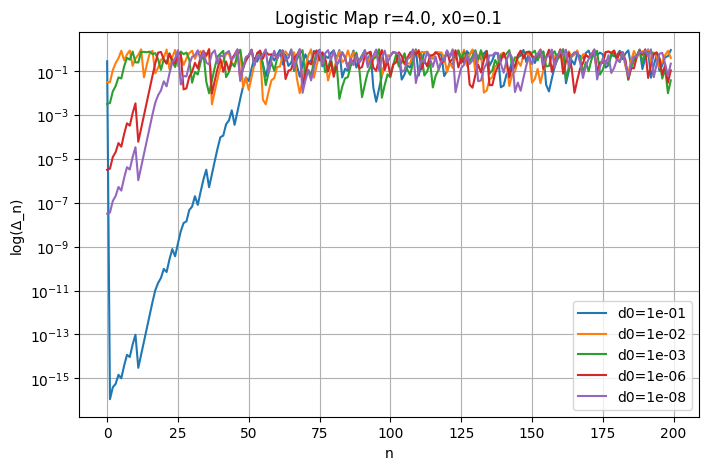

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def logistic(x, r=4.0):
    return r * x * (1 - x)

def pendiente(x,y):
    x = np.array(x)
    y = np.array(y)
    
    # Usamos polyfit de grado 1 (recta: y = m*x + b)
    pendiente, intercepto = np.polyfit(x, y, 1)
    return pendiente

r = 4.0
x0 = 0.1
deltas = [1e-1, 1e-2, 1e-3, 1e-6, 1e-8]   # incluye 0.1 similar a 10e-2
N = 200

trajectories = []
for d0 in deltas:
    x = x0
    y = x0 + d0
    D = []
    for n in range(N):
        x = logistic(x, r)
        y = logistic(y, r)
        D.append(abs(y - x))
    trajectories.append(np.array(D))

plt.figure(figsize=(8,5))
for d0, D in zip(deltas, trajectories):
    # evita log(0)
    Dsafe = np.maximum(D, 1e-16)
    plt.plot(np.arange(N), Dsafe, label=f"d0={d0:.0e}")
    plt.yscale("log")
    n = 50
    print(pendiente(np.arange(n), np.log(Dsafe[:n])))
    n = n-n//2
plt.xlabel("n")
plt.ylabel("log(Δ_n)")
plt.legend()
plt.title(f"Logistic Map r={r}, x0={x0}")
plt.grid(True)
plt.show()


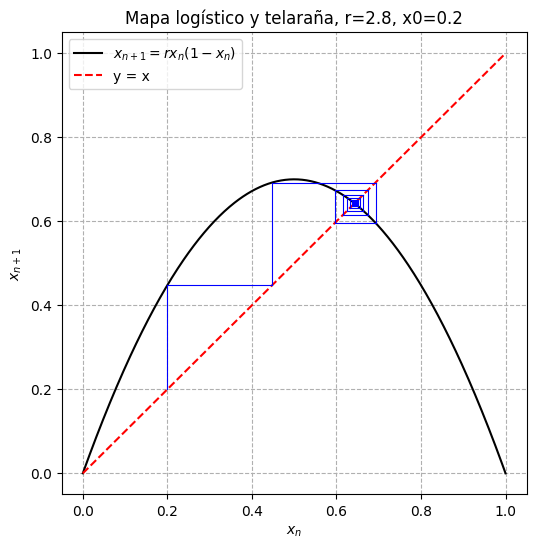

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
r = 2.8             # parámetro del mapa logístico
x0 = 0.2            # valor inicial
n_iter = 50         # número de iteraciones

# Función del mapa logístico
def logistic_map(x, r):
    return r * x * (1 - x)

# Generar puntos para la curva x_{n+1} vs x_n
x = np.linspace(0, 1, 500)
y = logistic_map(x, r)

# Preparar figura
plt.figure(figsize=(6,6))
plt.plot(x, y, 'k', label=r'$x_{n+1} = r x_n (1-x_n)$')  # curva
plt.plot(x, x, 'r--', label='y = x')                      # línea diagonal

# Generar telaraña (cobweb)
xn = x0
for i in range(n_iter):
    # Línea vertical hasta la curva
    plt.plot([xn, xn], [xn, logistic_map(xn, r)], color='blue', lw=0.8)
    # Línea horizontal hasta la diagonal
    plt.plot([xn, logistic_map(xn, r)], [logistic_map(xn, r), logistic_map(xn, r)], color='blue', lw=0.8)
    xn = logistic_map(xn, r)

plt.title(f'Mapa logístico y telaraña, r={r}, x0={x0}')
plt.xlabel(r'$x_n$')
plt.ylabel(r'$x_{n+1}$')
plt.legend()
plt.grid(True, ls='--')
plt.show()


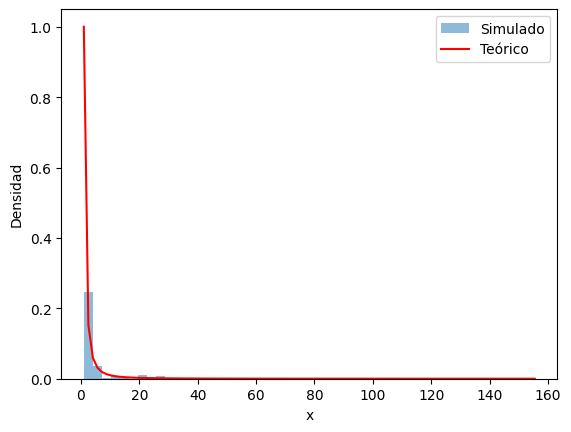

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

N = 10**4
x0 = 1
u = 2

w = np.random.uniform(0, 1, N)

x = x0 * (1 - w) ** (-1 / (u - 1))

t = np.linspace(x0, np.max(x), N)
teorico = (u-1)*x0**(u-1) * t**(-u)

plt.hist(x=x, bins=50, density=True, alpha=0.5, label='Simulado')
plt.plot(t, teorico, 'r-', label='Teórico')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.show()

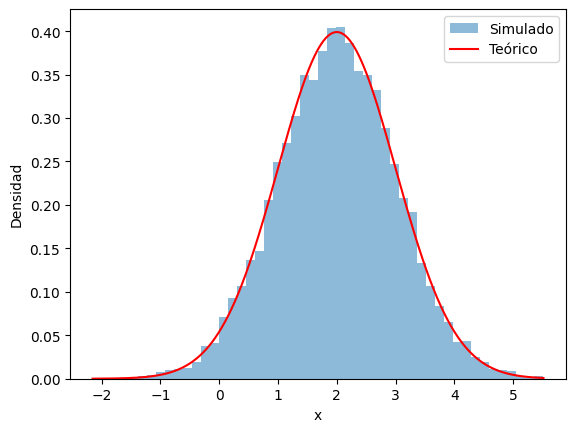

In [4]:
import numpy as np
import matplotlib.pyplot as plt 

N = 10**4
u = 2
var = 1

w1 = np.random.uniform(0, 1, N)
w2 = np.random.uniform(0, 1, N)

z1 = np.sqrt(-2 * np.log(w1)) * np.cos(2 * np.pi * w2) 
z2 = np.sqrt(-2 * np.log(w1)) * np.sin(2 * np.pi * w2)
x = np.sqrt(var) * z1 + u

t = np.linspace(np.min(x), np.max(x), N)
teorico = 1/np.sqrt(2*np.pi*var) * np.exp(-(t-u)**2 / (2*var))

plt.hist(x=x, bins=50, density=True, alpha=0.5, label='Simulado')
plt.plot(t, teorico, 'r-', label='Teórico')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.show()

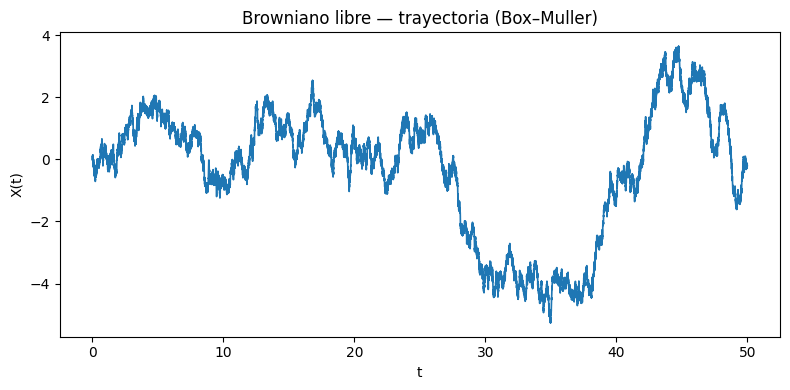

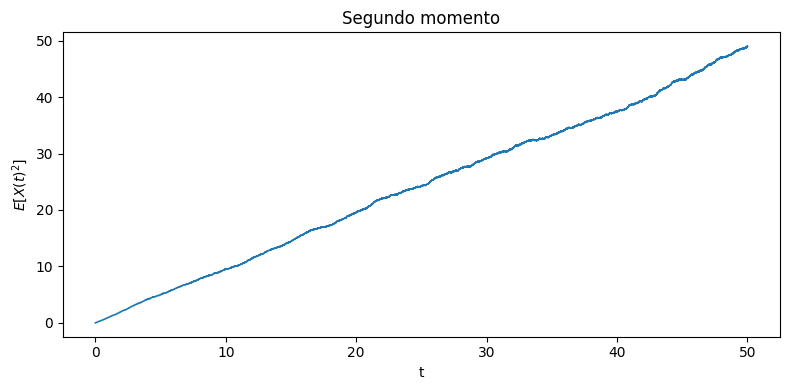

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def box_muller_normals(N, u=0.0, var=1.0):
 
    w1 = np.random.uniform(0, 1, N)
    w2 = np.random.uniform(0, 1, N)
    z1 = np.sqrt(-2 * np.log(w1)) * np.cos(2 * np.pi * w2) 
    x = np.sqrt(var) * z1 + u
    return x


def brownian_trajectory(D=0.5, dt=1e-3, T=50.0, x0=0.0):
    n = int(np.round(T / dt))  # número de pasos
    zetas = box_muller_normals(n, u=0.0, var=1.0)

    sigma = np.sqrt(2.0 * D * dt)
    inc = sigma * zetas

    X = np.empty(n + 1, dtype=float)
    X[0] = x0
    X[1:] = x0 + np.cumsum(inc)

    t = np.linspace(0.0, n * dt, n + 1)
    return t, X


if __name__ == "__main__":
    D,dt,T = 0.5, 1e-3, 50.0 
    n = int(np.round(T / dt))
    t, X = brownian_trajectory(D=D, dt=dt, T=T, x0=0.0)

    plt.figure(figsize=(8, 4))
    plt.plot(t, X, linewidth=1.2)
    plt.xlabel('t')
    plt.ylabel('X(t)')
    plt.title('Browniano libre — trayectoria (Box–Muller)')
    plt.tight_layout()
    plt.show()

    caminantes = np.zeros((2000,n+1))

    for i in range(2000):
        t,x = brownian_trajectory(D=D, dt=dt, T=T, x0=0.0)
        caminantes[i,:] = x

    plt.figure(figsize=(8, 4))
    plt.plot(t, np.mean(caminantes**2,axis=0), linewidth=1.2)
    plt.xlabel('t')
    plt.ylabel(r'$E[X(t)^2]$')
    plt.title('Segundo momento')
    plt.tight_layout()
    plt.show()

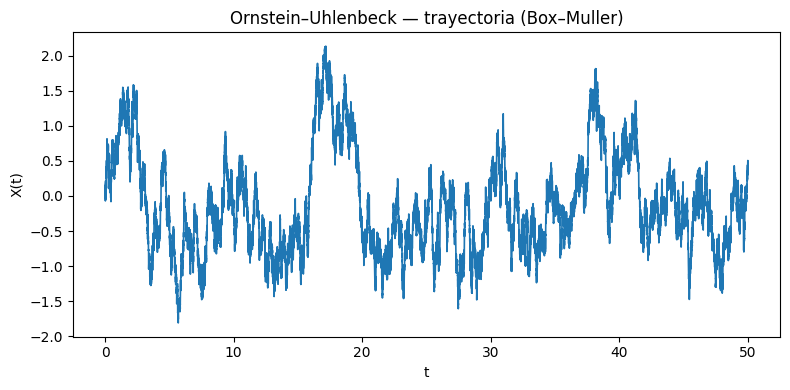

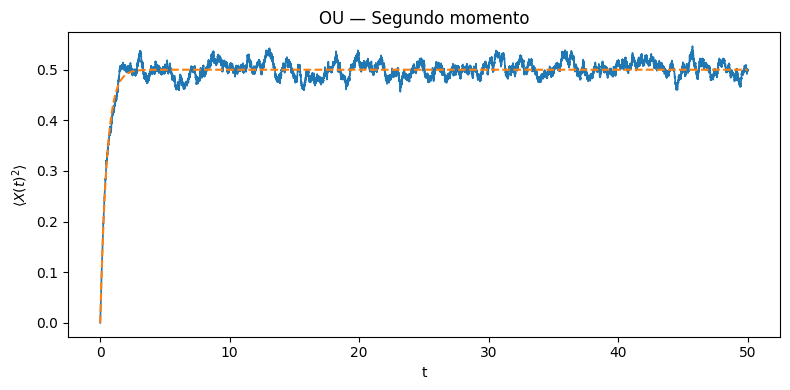

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def box_muller_normals(N, u=0.0, var=1.0):
    w1 = np.random.uniform(0, 1, N)
    w2 = np.random.uniform(0, 1, N)
    z1 = np.sqrt(-2 * np.log(w1)) * np.cos(2 * np.pi * w2)
    x = np.sqrt(var) * z1 + u
    return x

def ou_trajectory(D=0.5, dt=1e-3, T=50.0, x0=0.0):
    n = int(np.round(T / dt))  # número de pasos
    zetas = box_muller_normals(n, u=0.0, var=1.0)  # N(0,1)

    drift = 1.0 - dt
    sigma = np.sqrt(2.0 * D * dt)

    X = np.empty(n + 1, dtype=float)
    X[0] = x0
    for k in range(n):
        X[k+1] = drift * X[k] + sigma * zetas[k]

    t = np.linspace(0.0, n * dt, n + 1)
    return t, X

if __name__ == "__main__":
    D, dt, T = 0.5, 1e-3, 50.0
    n = int(np.round(T / dt))
    t, X = ou_trajectory(D=D, dt=dt, T=T, x0=0.0)

    plt.figure(figsize=(8, 4))
    plt.plot(t, X, linewidth=1.2)
    plt.xlabel('t')
    plt.ylabel('X(t)')
    plt.title('Ornstein–Uhlenbeck — trayectoria (Box–Muller)')
    plt.tight_layout()
    plt.show()

    # Ensemble de caminantes
    caminantes = np.zeros((2000, n+1))
    for i in range(2000):
        _, x = ou_trajectory(D=D, dt=dt, T=T, x0=0.0)
        caminantes[i, :] = x

    msd = np.mean(caminantes**2, axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(t, msd, linewidth=1.2, label=r'$\langle X(t)^2\rangle$ (num)')
    # Línea teórica opcional (descomenta si quieres comparar):
    plt.plot(t, D*(1 - np.exp(-2*t)), '--', label='D(1 - e^{-2t}) (teoría)')
    plt.xlabel('t')
    plt.ylabel(r'$\langle X(t)^2\rangle$')
    plt.title('OU — Segundo momento')
    # plt.legend()
    plt.tight_layout()
    plt.show()


media muestral    ≈ 0.0920   (teórica 0)
varianza muestral ≈ 1.1174  (teórica D=1.0)


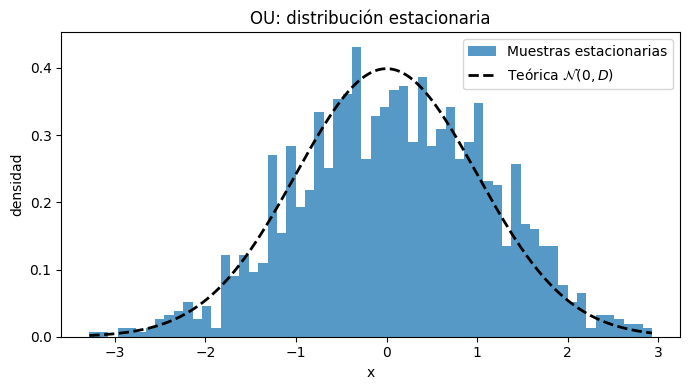

In [ ]:
# --- Comprobación estacionaria OU (inciso d) ---
def ou_stationary_check(D=1.0, dt=1e-3, T=200.0, burn=50.0, stride=100):
    # trayectoria larga
    t, x = ou_trajectory(D=D, dt=dt, T=T, x0=0.0)
    # descartar transitorio
    b = int(burn/dt)
    # submuestreo para reducir correlación (~e^{-tau})
    samples = x[b::stride]
    # estadísticas muestrales
    mu_hat  = samples.mean()
    var_hat = samples.var()

    print(f"media muestral    ≈ {mu_hat:.4f}   (teórica 0)")
    print(f"varianza muestral ≈ {var_hat:.4f}  (teórica D={D})")

    # histograma vs. pdf teórica N(0, D)
    import numpy as np
    import matplotlib.pyplot as plt
    grid = np.linspace(samples.min(), samples.max(), 500)
    pst = (1/np.sqrt(2*np.pi*D)) * np.exp(-grid**2/(2*D))

    plt.figure(figsize=(7,4))
    plt.hist(samples, bins=60, density=True, alpha=0.75, label='Muestras estacionarias')
    plt.plot(grid, pst, 'k--', lw=2, label=r'Teórica $\mathcal{N}(0,D)$')
    plt.xlabel('x'); plt.ylabel('densidad')
    plt.title('OU: distribución estacionaria')
    plt.legend(); plt.tight_layout(); plt.show()


ou_stationary_check(D=1.0, dt=1e-3, T=200.0, burn=50.0, stride=100)


[6.47120109e-04 2.58680538e-03 1.03204553e-02 ... 7.76726302e-01
 6.93690215e-01 8.49936402e-01]


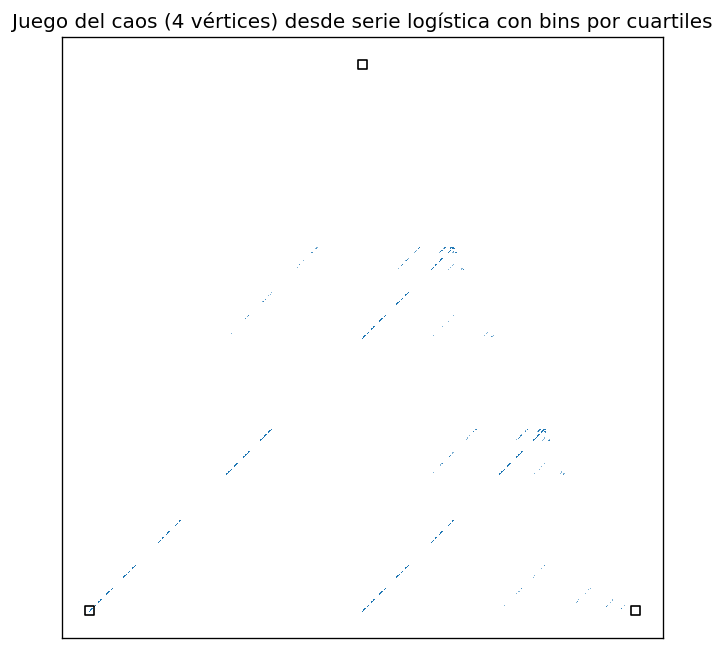

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1) Serie del mapa logístico
# ---------------------------
def logistic_series(r=3.2, x0=0.123456, N=20000, burnin=1000):
    """Genera serie del mapa logístico y descarta un transitorio (burn-in)."""
    x = np.empty(N + burnin, dtype=np.float64)
    x[0] = np.clip(x0, 0, 1)
    for i in range(N + burnin - 1):
        x[i+1] = r * x[i] * (1.0 - x[i])
    return x[burnin:]  # descarta transitorio

# ------------------------------------------------
# 2) Binning en 4 segmentos con frecuencias iguales
# ------------------------------------------------
def bins_equal_freq_4(arr):
    """
    Devuelve etiquetas 0..3 con (casi) el mismo número de puntos en cada bin.
    Método: ranking estable y corte por cuartas partes del rango.
    """
    n = len(arr)
    # ranking: posiciones 0..n-1 de menor a mayor, estable para empates
    order = np.argsort(arr, kind='mergesort')
    rank = np.empty(n, dtype=np.int64)
    rank[order] = np.arange(n, dtype=np.int64)
    # 4 bloques por rango
    labels = (rank * 3) // n
    labels = np.clip(labels, 0, 2).astype(np.int8)
    return labels

# --------------------------------------
# 3) Juego del caos para 4 vértices
# --------------------------------------
def chaos_game_4(labels, alpha=0.5, vertices=None, start=(0.5, 0.5)):
    """
    labels: array de enteros en {0,1,2,3}
    alpha: fracción de avance hacia el vértice
    vertices: 4x2, si None usa cuadrado unitario en sentido horario
    """
    if vertices is None:
        # Asociaremos: 0->(0,0), 1->(1,0), 2->(1,1), 3->(0,1)
        vertices = np.array([[0.0, 0.0],
                             [2.0, 0.0],
                             [1.0, 2.0]], dtype=np.float64)

    pts = np.empty((len(labels), 2), dtype=np.float64)
    x, y = float(start[0]), float(start[1])
    for i, lab in enumerate(labels):
        vx, vy = vertices[lab]
        x = alpha * x + alpha * vx
        y = alpha * y + alpha * vy
        pts[i, 0] = x
        pts[i, 1] = y
    return pts

# ---------------------------
# 4) Ejecutar y visualizar
# ---------------------------
if __name__ == "__main__":
    # Parámetros
    r = 4.0
    x0 = 0.327
    N = 1_000_000           # >= 5000 como pediste
    burnin = 2000
    alpha = 0.5

    # Serie logística
    xs = logistic_series(r=r, x0=x0, N=N, burnin=burnin)
    # xs = np.random.rand(N)
    # Etiquetas por cuartiles (frecuencias iguales)
    labels = bins_equal_freq_4(xs)

    # Juego del caos (4 vértices)
    points = chaos_game_4(labels, alpha=alpha)

    # Plot
    fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=120)
    ax.scatter(points[:, 0], points[:, 1], s=0.2, linewidths=0, alpha=0.8)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("Juego del caos (4 vértices) desde serie logística con bins por cuartiles")
    # Opcional: dibuja los vértices
    # V = np.array([[0,0],[1,0],[1,1],[0,1]], dtype=float)
    V = np.array([[0,0],[2,0],[1,2]], dtype=float)
    ax.scatter(V[:,0], V[:,1], s=30, marker="s", edgecolor="k", facecolor="none")
    plt.show()
